# Moving Average filter



Segment 1/251 — RMSE: 29.00 | MAPE: 1.45% | R²: 0.5219 | Dir Acc: 46.7%
Segment 2/251 — RMSE: 36.19 | MAPE: 1.87% | R²: 0.5530 | Dir Acc: 53.3%
Segment 3/251 — RMSE: 28.20 | MAPE: 1.06% | R²: 0.1647 | Dir Acc: 46.7%
Segment 4/251 — RMSE: 32.07 | MAPE: 1.70% | R²: 0.0050 | Dir Acc: 43.3%
Segment 5/251 — RMSE: 54.51 | MAPE: 2.66% | R²: 0.1895 | Dir Acc: 46.7%
Segment 6/251 — RMSE: 81.78 | MAPE: 3.75% | R²: 0.4434 | Dir Acc: 66.7%
Segment 7/251 — RMSE: 66.94 | MAPE: 2.85% | R²: 0.6971 | Dir Acc: 46.7%
Segment 8/251 — RMSE: 18.66 | MAPE: 0.78% | R²: 0.3589 | Dir Acc: 46.7%
Segment 9/251 — RMSE: 22.18 | MAPE: 0.99% | R²: 0.4154 | Dir Acc: 53.3%
Segment 10/251 — RMSE: 19.16 | MAPE: 0.87% | R²: 0.5868 | Dir Acc: 53.3%
Segment 11/251 — RMSE: 35.31 | MAPE: 1.50% | R²: 0.1945 | Dir Acc: 40.0%
Segment 12/251 — RMSE: 37.38 | MAPE: 1.66% | R²: 0.5170 | Dir Acc: 56.7%
Segment 13/251 — RMSE: 58.29 | MAPE: 2.57% | R²: 0.0121 | Dir Acc: 53.3%
Segment 14/251 — RMSE: 108.89 | MAPE: 4.04% | R²: 0.0053 | D

/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/ipykernel_29602/4002582638.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


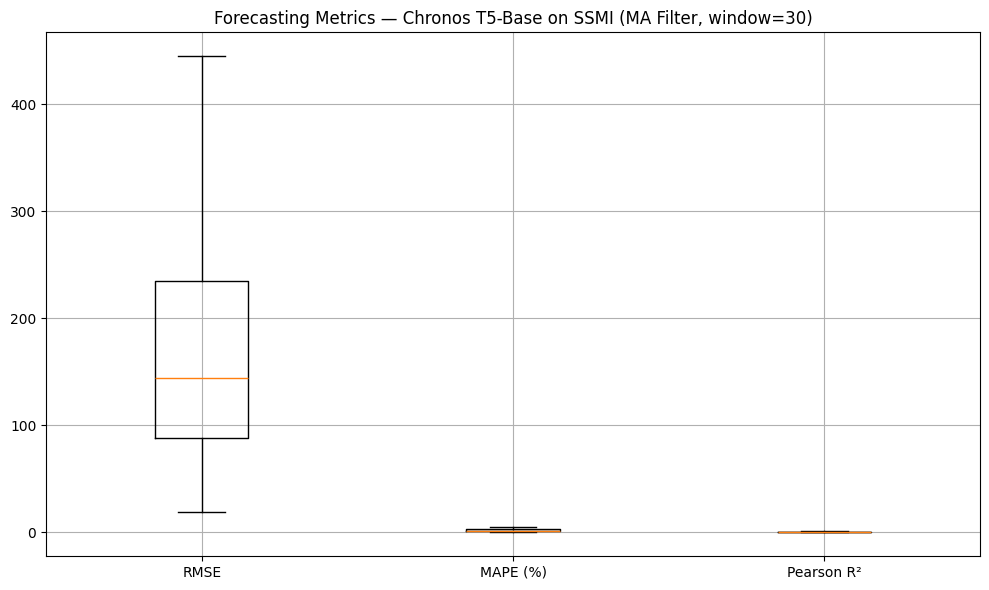

In [20]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

logging.basicConfig(
    filename='ChronosBase_SSMI_Filtered_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def moving_average_filter(y, window=20):
    """Smooth the signal using a moving average (low-frequency trend)."""
    low = np.convolve(y, np.ones(window)/window, mode='same')
    high = y - low  # residual / high-frequency component
    return low, high

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Apply filter
        # ========================
        filter_window = 30  # 30-day moving average (approx. 1 trading month)
        y_low, y_high = moving_average_filter(y, window=filter_window)
        logging.info(f"Moving average filter applied with window={filter_window}")

        # ========================
        # 3) Sliding window config
        # ========================
        context_window   = 120 # 200
        forecast_horizon = 30
        step_size        = 30 # context_window + forecast_horizon
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 4) Load Chronos
        # ========================
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-base",
            device_map="mps",
            torch_dtype=torch.float32,
        )
        logging.info("Chronos T5-Base loaded successfully.")

        # ========================
        # 5) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        pearson_list     = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            # Split context into low and high components
            context_low  = torch.tensor(y_low[start_context:end_context].copy(),  dtype=torch.float32)
            context_high = torch.tensor(y_high[start_context:end_context].copy(), dtype=torch.float32)

            # True values (recombined)
            true_low      = y_low[end_context:end_context + forecast_horizon]
            true_high     = y_high[end_context:end_context + forecast_horizon]
            true_combined = true_low + true_high

            # Forecast low-frequency (trend)
            forecast_low = pipeline.predict(
                context_low,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            # Forecast high-frequency (residual)
            forecast_high = pipeline.predict(
                context_high,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            # Recombine predictions
            median_low    = np.median(forecast_low[0].numpy(),  axis=0)
            median_high   = np.median(forecast_high[0].numpy(), axis=0)
            combined_pred = median_low + median_high

            prev_values = np.concatenate([[y[end_context - 1]], true_combined[:-1]])
            pred_prev   = np.concatenate([[y[end_context - 1]], combined_pred[:-1]])
            actual_direction = np.sign(true_combined - prev_values)
            pred_direction   = np.sign(combined_pred - pred_prev)
            hits = (actual_direction == pred_direction).astype(int)
            segment_dir_acc = hits.mean() * 100
            directional_hits.extend(hits.tolist())

            # Metrics
            rmse       = np.sqrt(mean_squared_error(true_combined, combined_pred))
            mape       = mean_absolute_percentage_error(true_combined, combined_pred) * 100
            pearson_r2 = pearsonr(true_combined, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(pearson_r2)

            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, Pearson R²={pearson_r2:.4f}, DirAcc={segment_dir_acc:.1f}%")
            print(f"Segment {segment+1}/{num_segments} — RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R²: {pearson_r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%")

        # ========================
        # 6) Save results
        # ========================
        np.savez_compressed("ChronosBase_SSMI_Filtered_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            pearson_coefficients=np.array(pearson_list),
                            directional_hits=np.array(directional_hits),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            filter_window=filter_window,
                            num_segments=num_segments)
        logging.info("Results saved to ChronosBase_SSMI_Filtered_Metrics.npz")

        # ========================
        # 7) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100

        print("\n--- Median Metrics for Chronos T5-Base on SSMI (Filtered) ---")
        print(f"Median RMSE:       {np.median(rmse_list):.4f}")
        print(f"Median MAPE:       {np.median(mape_list):.4f}%")
        print(f"Median Pearson R²: {np.median(pearson_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 8) Box plots
        # ========================
        metrics = {
            "RMSE":       rmse_list,
            "MAPE (%)":   mape_list,
            "Pearson R²": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title(f"Forecasting Metrics — Chronos T5-Base on SSMI (MA Filter, window={filter_window})")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check ChronosBase_SSMI_Filtered_Metrics.log for details.")
        try:
            np.savez_compressed("partial_ChronosBase_SSMI_Filtered_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None,
                                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()

# Hodrick–Prescott filter

Segment 1/251 — RMSE: 40.69 | MAPE: 2.07% | R²: 0.0193 | Dir Acc: 33.3%
Segment 2/251 — RMSE: 27.83 | MAPE: 1.51% | R²: 0.6154 | Dir Acc: 36.7%
Segment 3/251 — RMSE: 31.15 | MAPE: 1.25% | R²: 0.0183 | Dir Acc: 53.3%
Segment 4/251 — RMSE: 28.37 | MAPE: 1.54% | R²: 0.0394 | Dir Acc: 43.3%
Segment 5/251 — RMSE: 37.08 | MAPE: 1.78% | R²: 0.3498 | Dir Acc: 50.0%
Segment 6/251 — RMSE: 56.73 | MAPE: 2.80% | R²: 0.6357 | Dir Acc: 66.7%
Segment 7/251 — RMSE: 13.66 | MAPE: 0.62% | R²: 0.8798 | Dir Acc: 56.7%
Segment 8/251 — RMSE: 32.62 | MAPE: 1.61% | R²: 0.6817 | Dir Acc: 50.0%
Segment 9/251 — RMSE: 33.78 | MAPE: 1.38% | R²: 0.3271 | Dir Acc: 40.0%
Segment 10/251 — RMSE: 31.90 | MAPE: 1.49% | R²: 0.4891 | Dir Acc: 53.3%
Segment 11/251 — RMSE: 30.05 | MAPE: 1.35% | R²: 0.1933 | Dir Acc: 56.7%
Segment 12/251 — RMSE: 62.63 | MAPE: 2.64% | R²: 0.5994 | Dir Acc: 46.7%
Segment 13/251 — RMSE: 26.81 | MAPE: 1.16% | R²: 0.1680 | Dir Acc: 70.0%
Segment 14/251 — RMSE: 45.79 | MAPE: 1.87% | R²: 0.8920 | Di

/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/ipykernel_29602/2440676937.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


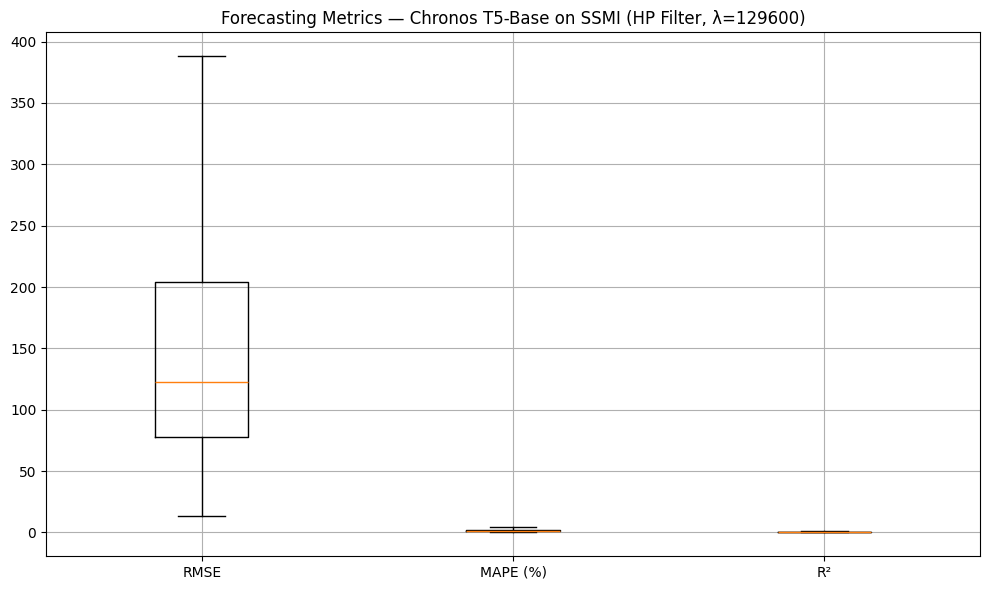

In [19]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.filters.hp_filter import hpfilter

logging.basicConfig(
    filename='ChronosBase_SSMI_HP_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Apply HP filter
        # ========================
        lamb = 129600
        cycle, trend = hpfilter(y, lamb=lamb)
        y_low  = trend
        y_high = cycle
        logging.info(f"HP filter applied with lambda={lamb}")

        # ========================
        # 3) Sliding window config
        # ========================
        context_window   = 120 # 200 
        forecast_horizon = 30
        step_size        = 30 # context_window + forecast_horizon
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 4) Load Chronos
        # ========================
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-base",
            device_map="mps",
            torch_dtype=torch.float32,
        )
        logging.info("Chronos T5-Base loaded successfully.")

        # ========================
        # 5) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        r2_list          = []
        directional_hits = []  # 1 if direction correct (up or down), 0 otherwise

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            context_low  = torch.tensor(y_low[start_context:end_context].copy(),  dtype=torch.float32)
            context_high = torch.tensor(y_high[start_context:end_context].copy(), dtype=torch.float32)

            true_low      = y_low[end_context:end_context + forecast_horizon]
            true_high     = y_high[end_context:end_context + forecast_horizon]
            true_combined = true_low + true_high

            forecast_low = pipeline.predict(
                context_low,
                prediction_length=forecast_horizon,
                num_samples=20,
            )
            forecast_high = pipeline.predict(
                context_high,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            median_low    = np.median(forecast_low[0].numpy(),  axis=0)
            median_high   = np.median(forecast_high[0].numpy(), axis=0)
            combined_pred = median_low + median_high

            # ========================
            # Directional accuracy
            # (correct up AND correct down)
            # ========================
            prev_day_price = y[end_context - 1]

            # Previous day anchor for actual and forecast
            actual_prev = np.concatenate([[prev_day_price], true_combined[:-1]])
            pred_prev   = np.concatenate([[prev_day_price], combined_pred[:-1]])

            actual_direction = np.sign(true_combined - actual_prev)  # +1 up, -1 down, 0 flat
            pred_direction   = np.sign(combined_pred  - pred_prev)   # +1 up, -1 down, 0 flat

            # 1 point if direction matches (both up or both down)
            hits = (actual_direction == pred_direction).astype(int)
            directional_hits.extend(hits.tolist())

            # Standard metrics
            rmse = np.sqrt(mean_squared_error(true_combined, combined_pred))
            mape = mean_absolute_percentage_error(true_combined, combined_pred) * 100
            r2 = pearsonr(true_combined, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            r2_list.append(r2)

            segment_dir_acc = hits.mean() * 100
            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, R²={r2:.4f}, DirAcc={segment_dir_acc:.1f}%")
            print(f"Segment {segment+1}/{num_segments} — RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%")

        # ========================
        # 6) Save results
        # ========================
        np.savez_compressed("ChronosBase_SSMI_HP_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            r2=np.array(r2_list),
                            directional_hits=np.array(directional_hits),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            lamb=lamb,
                            num_segments=num_segments)
        logging.info("Results saved to ChronosBase_SSMI_HP_Metrics.npz")

        # ========================
        # 7) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100

        print("\n--- Median Metrics for Chronos T5-Base on SSMI (HP Filter) ---")
        print(f"Median RMSE:          {np.median(rmse_list):.4f}")
        print(f"Median MAPE:          {np.median(mape_list):.4f}%")
        print(f"Median R²:            {np.median(r2_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 8) Box plots
        # ========================
        metrics = {
            "RMSE":     rmse_list,
            "MAPE (%)": mape_list,
            "R²":       r2_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title(f"Forecasting Metrics — Chronos T5-Base on SSMI (HP Filter, λ={lamb})")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check ChronosBase_SSMI_HP_Metrics.log for details.")
        try:
            np.savez_compressed("partial_ChronosBase_SSMI_HP_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                r2=np.array(r2_list) if 'r2_list' in locals() else None,
                                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()

# 5 Hz Cutoff (butter worth filter)

Segment 1/251 — RMSE: 70.59 | MAPE: 3.53% | R²: 0.3289 | Dir Acc: 40.0%
Segment 2/251 — RMSE: 79.53 | MAPE: 3.64% | R²: 0.6235 | Dir Acc: 33.3%
Segment 3/251 — RMSE: 28.84 | MAPE: 1.07% | R²: 0.1778 | Dir Acc: 50.0%
Segment 4/251 — RMSE: 30.20 | MAPE: 1.59% | R²: 0.0006 | Dir Acc: 50.0%
Segment 5/251 — RMSE: 53.39 | MAPE: 2.56% | R²: 0.4363 | Dir Acc: 46.7%
Segment 6/251 — RMSE: 74.43 | MAPE: 3.42% | R²: 0.7810 | Dir Acc: 30.0%
Segment 7/251 — RMSE: 91.00 | MAPE: 3.78% | R²: 0.8043 | Dir Acc: 33.3%
Segment 8/251 — RMSE: 93.37 | MAPE: 3.97% | R²: 0.6224 | Dir Acc: 56.7%
Segment 9/251 — RMSE: 16.53 | MAPE: 0.71% | R²: 0.6301 | Dir Acc: 46.7%
Segment 10/251 — RMSE: 101.14 | MAPE: 4.49% | R²: 0.5584 | Dir Acc: 56.7%
Segment 11/251 — RMSE: 39.41 | MAPE: 1.65% | R²: 0.0000 | Dir Acc: 40.0%
Segment 12/251 — RMSE: 34.29 | MAPE: 1.56% | R²: 0.6639 | Dir Acc: 46.7%
Segment 13/251 — RMSE: 69.28 | MAPE: 2.92% | R²: 0.0350 | Dir Acc: 46.7%
Segment 14/251 — RMSE: 144.85 | MAPE: 5.70% | R²: 0.8926 | 

/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/ipykernel_29602/4061383234.py:197: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


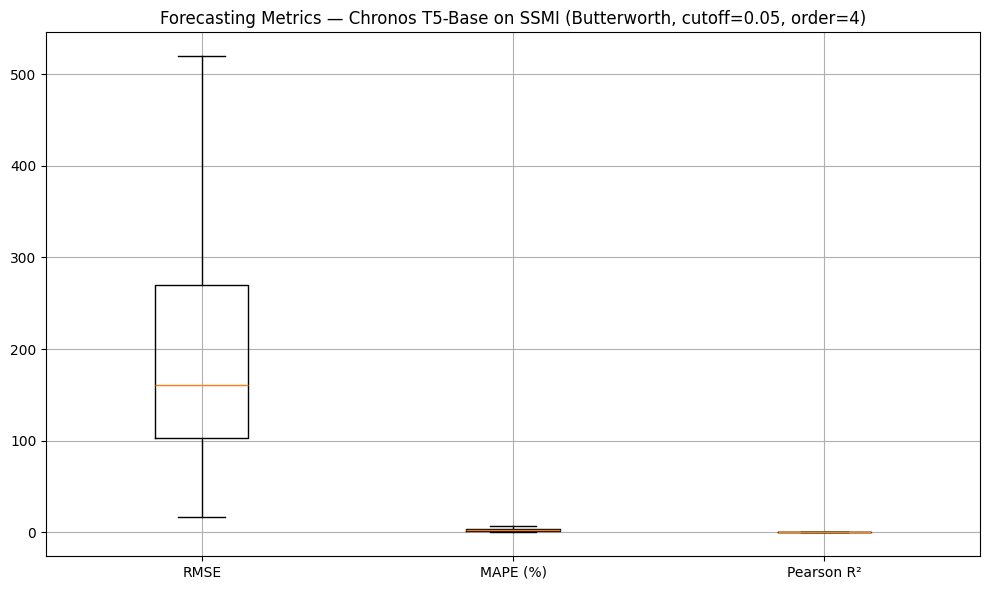

In [23]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt

logging.basicConfig(
    filename='ChronosBase_SSMI_Butterworth_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def butterworth_filter(y, cutoff=0.05, order=4):
    """
    Low-pass Butterworth filter.
    
    Parameters
    ----------
    y : array-like
        Input time series.
    cutoff : float
        Normalized cutoff frequency in (0, 1), where 1 corresponds to Nyquist.
    order : int
        Filter order.

    Returns
    -------
    low : np.ndarray
        Low-frequency component.
    high : np.ndarray
        High-frequency residual component.
    """
    b, a = butter(order, cutoff, btype='low')
    low = filtfilt(b, a, y)
    high = y - low
    return low, high

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv(
            "/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv",
            parse_dates=["Date"]
        )
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Apply Butterworth filter
        # ========================
        cutoff = 0.05
        filter_order = 4
        y_low, y_high = butterworth_filter(y, cutoff=cutoff, order=filter_order)
        logging.info(f"Butterworth filter applied with cutoff={cutoff}, order={filter_order}")

        # ========================
        # 3) Sliding window config
        # ========================
        context_window   = 120 # 200
        forecast_horizon = 30
        step_size        = 30 # context_window + forecast_horizon
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 4) Load Chronos
        # ========================
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-base",
            device_map="mps",
            torch_dtype=torch.float32,
        )
        logging.info("Chronos T5-Base loaded successfully.")

        # ========================
        # 5) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        pearson_list     = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window

            if end_context + forecast_horizon > total_samples:
                break

            # Split context into low/high components
            context_low  = torch.tensor(y_low[start_context:end_context].copy(), dtype=torch.float32)
            context_high = torch.tensor(y_high[start_context:end_context].copy(), dtype=torch.float32)

            # True values
            true_low      = y_low[end_context:end_context + forecast_horizon]
            true_high     = y_high[end_context:end_context + forecast_horizon]
            true_combined = y[end_context:end_context + forecast_horizon]

            # Forecast low component
            forecast_low = pipeline.predict(
                context_low,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            # Forecast high component
            forecast_high = pipeline.predict(
                context_high,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            # Recombine predictions
            median_low    = np.median(forecast_low[0].numpy(), axis=0)
            median_high   = np.median(forecast_high[0].numpy(), axis=0)
            combined_pred = median_low + median_high

            # Directional accuracy
            prev_values = np.concatenate([[y[end_context - 1]], true_combined[:-1]])
            pred_prev   = np.concatenate([[y[end_context - 1]], combined_pred[:-1]])

            actual_direction = np.sign(true_combined - prev_values)
            pred_direction   = np.sign(combined_pred - pred_prev)

            hits = (actual_direction == pred_direction).astype(int)
            segment_dir_acc = hits.mean() * 100
            directional_hits.extend(hits.tolist())

            # Metrics
            rmse       = np.sqrt(mean_squared_error(true_combined, combined_pred))
            mape       = mean_absolute_percentage_error(true_combined, combined_pred) * 100
            pearson_r2 = pearsonr(true_combined, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(pearson_r2)

            logging.info(
                f"Segment {segment+1}/{num_segments}: "
                f"RMSE={rmse:.4f}, MAPE={mape:.4f}%, Pearson R²={pearson_r2:.4f}, DirAcc={segment_dir_acc:.1f}%"
            )
            print(
                f"Segment {segment+1}/{num_segments} — "
                f"RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R²: {pearson_r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%"
            )

        # ========================
        # 6) Save results
        # ========================
        np.savez_compressed(
            "ChronosBase_SSMI_Butterworth_Metrics.npz",
            rmse=np.array(rmse_list),
            mape=np.array(mape_list),
            pearson_coefficients=np.array(pearson_list),
            directional_hits=np.array(directional_hits),
            context_window=context_window,
            forecast_horizon=forecast_horizon,
            cutoff=cutoff,
            filter_order=filter_order,
            num_segments=num_segments
        )
        logging.info("Results saved to ChronosBase_SSMI_Butterworth_Metrics.npz")

        # ========================
        # 7) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100 if total_days > 0 else 0.0

        print("\n--- Median Metrics for Chronos T5-Base on SSMI (Butterworth Filter) ---")
        print(f"Median RMSE:       {np.median(rmse_list):.4f}")
        print(f"Median MAPE:       {np.median(mape_list):.4f}%")
        print(f"Median Pearson R²: {np.median(pearson_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 8) Box plots
        # ========================
        metrics = {
            "RMSE":       rmse_list,
            "MAPE (%)":   mape_list,
            "Pearson R²": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title(
            f"Forecasting Metrics — Chronos T5-Base on SSMI "
            f"(Butterworth, cutoff={cutoff}, order={filter_order})"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check ChronosBase_SSMI_Butterworth_Metrics.log for details.")
        try:
            np.savez_compressed(
                "partial_ChronosBase_SSMI_Butterworth_Metrics.npz",
                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None,
                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None
            )
        except Exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()